In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, brier_score_loss, log_loss, average_precision_score, accuracy_score
from sklearn.calibration import calibration_curve

In [2]:
df1 = pd.read_csv('https://raw.githubusercontent.com/gr33dy1/Diploma/refs/heads/main/Diploma%20codes/Models/data_for_models.csv')
X = df1.drop(['is_canceled'], axis=1)
y = df1['is_canceled']

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [4]:
def calibr_error(y_true, y_proba, n_bins=10):
  y_true = np.array(y_true)
  y_proba = np.array(y_proba)
  bins = np.linspace(0, 1, n_bins+1)
  bin_ids = np.digitize(y_proba, bins) - 1
  ece = 0
  for i in range(n_bins):
    bin_mask=bind_ids=i
    if np.sum(bin_mask) > 0:
      bin_conf = np.mean(y_proba[bin_mask])
      bin_acc = np.mean(y_true[bin_mask])
      ece += (np.sum(bin_mask) / len(y_true)) * abs(bin_acc - bin_conf)
  return ece

In [5]:
models = {
    'LogReg': {
        'model': LogisticRegression(random_state=42, class_weight='balanced'),
        'parametr_verification': 'grid',
        'params': {
            'max_iter': [500, 1000, 2000],
            'C': [0.01, 0.1, 1],
            'class_weight': ['balanced']
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        'parametr_verification': 'grid',
        'params': {
            'criterion': ['gini', 'entropy'],
            'max_depth': [3, 5, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4, 8]
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
        'parametr_verification': 'random',
        'params': {
            'n_estimators': [200, 300, 500, 700],
            'max_depth': [3, 5, 8, 10],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [2, 4, 8]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', scale_pos_weight=2, subsample=0.8, colsample_bytree=0.8),
        'parametr_verification': 'random',
        'params': {
            'n_estimators': [200, 300, 500, 700],
            'max_depth': [3, 5, 8, 10],
            'learning_rate': [0.01, 0.05, 0.1],
            'min_child_weight': [1, 3, 5],
            'gamma': [0, 0.1, 0.3],
            'reg_alpa': [0, 0.01, 0.1],
            'reg_lambda': [1, 3, 5]
        }
    }
}

In [6]:
results_new = []
best_models = {}
test_predictions = {}

for model_name, config in models.items():
    print(f'\nОбучается модель: {model_name}')
    estimator = config['model']
    if config['parametr_verification'] == 'grid':
        search = GridSearchCV(
            estimator=estimator,
            param_grid=config['params'],
            scoring='roc_auc',
            cv=cv,
            n_jobs=-1,
            refit=True,
            verbose=1
        )
    elif config['parametr_verification'] == 'random':
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=config['params'],
            n_iter=30,
            scoring='roc_auc',
            cv=cv,
            n_jobs=-1,
            refit=True,
            random_state=42,
            verbose=1
        )

    search.fit(X_train, y_train)
    best_model = search.best_estimator_
    y_proba = best_model.predict_proba(X_test)[:, 1]
    y_pred = (y_proba >= 0.5).astype(int)

    result = {
        'model': model_name,
        'parametr_verification': config['parametr_verification'],
        'best_cv_roc_auc': search.best_score_,
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'test_precision': precision_score(y_test, y_pred, zero_division=0),
        'test_recall': recall_score(y_test, y_pred, zero_division=0),
        'test_f1': f1_score(y_test, y_pred, zero_division=0),
        'test_brier_score': brier_score_loss(y_test, y_proba),
        'test_log_loss': log_loss(y_test, y_proba),
        'test_pr_auc': average_precision_score(y_test, y_proba),
        'test_ece': calibr_error(y_test, y_proba, n_bins=10),
        'best_params': search.best_params_
    }

    results_new.append(result)
    best_models[model_name] = best_model
    test_predictions[model_name] = {
        'y_true': y_test.values,
        'y_proba': y_proba,
        'y_pred': y_pred
    }


Обучается модель: LogReg
Fitting 5 folds for each of 9 candidates, totalling 45 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Обучается модель: DecisionTree
Fitting 5 folds for each of 54 candidates, totalling 270 fits

Обучается модель: RandomForest
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Обучается модель: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:28:56] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "reg_alpa" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [8]:
results_df = pd.DataFrame(results_new)
results_df

,model,parametr_verification,best_cv_roc_auc,test_roc_auc,test_precision,test_recall,test_f1,test_brier_score,test_log_loss,test_pr_auc,test_ece,best_params
0,LogReg,grid,0.836501,0.840192,0.664873,0.737903,0.699487,0.160783,0.476237,0.811761,0.000669,"{'C': 0.01, 'class_weight': 'balanced', 'max_i..."
1,DecisionTree,grid,0.876577,0.879385,0.783504,0.695982,0.737154,0.136270,0.429669,0.829810,0.000510,"{'criterion': 'gini', 'max_depth': 10, 'min_sa..."
2,RandomForest,random,0.890523,0.891288,0.829111,0.671725,0.742166,0.138460,0.430044,0.867455,0.000692,"{'n_estimators': 300, 'min_samples_split': 5, ..."
3,XGBoost,random,0.914977,0.918830,0.760751,0.831820,0.794700,0.116264,0.358227,0.898015,0.000367,"{'reg_lambda': 3, 'reg_alpa': 0.01, 'n_estimat..."


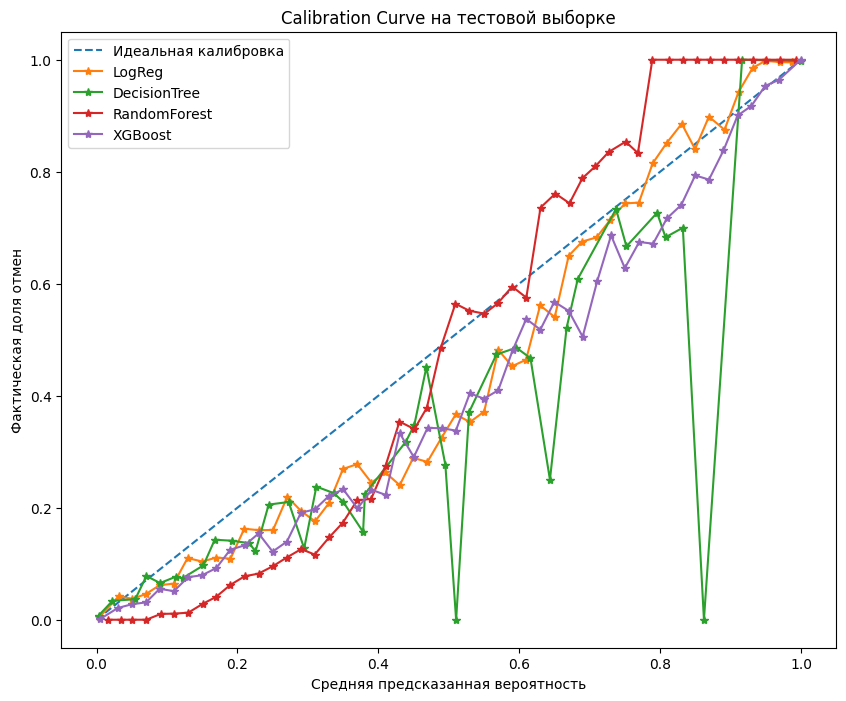

In [11]:
plt.figure(figsize=(10, 8))
plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Фактическая доля отмен')
plt.title('Calibration Curve на тестовой выборке')
x = np.linspace(0, 1, 2)
plt.plot(x, x, linestyle='--', label='Идеальная калибровка')

for model_name, preds in test_predictions.items():
    y_true = preds['y_true']
    y_proba = preds['y_proba']
    prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=50, strategy='uniform')
    plt.plot(prob_pred, prob_true, label=model_name, marker='*')

plt.legend()